# ASWANTH K

## DATA ANALYTICS INTERNSHIP

### TASK 2 – Customer Segmentation

***OASIS INFOBYTE***

# **Customer Segmentation Analysis using K-Means Clustering**

**Objective**

The Objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. The insights will help identify different customer groups and recommend targeted marketing strategies.

### **1. Import Required Libraries**
The first step is to import all the libraries required for data manipulation, visualization, preprocessing, and ,machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings("ignore")

**2. Load the Dataset**

The Online Retail dataset is loaded into a pandas DataFrame for inspection and analysis.

In [2]:
df=pd.read_csv ("/content/Online_Retail.csv", encoding="latin1")

**3. Data Inspection**

Before cleaning the data, it is important to understand the dataset by checking:

*Number of rows and columns

*Data types

*Sample records

*Missing values

*Duplicate records

*Summary statistics

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


# **Data Inspection**

From the initial inspection, the dataset contains customer transaction records including invoice information, product descriptions, quantities, prices, invoice dates, and customer IDs. The Inspection also helps identify missing values and duplicate records that need to be handled before performing customer segmentation.

# **2. Data Cleaning**
Data cleaning is performed to improve the quality of the dataset before analysis. The following steps are carried out:

*Remove duplicate records

*Remove rows with missing CustomerID values

*Verify that the cleaned dataset contains no missing values

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.dropna(subset=["CustomerID"], inplace=True)

In [11]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


# **Data Cleaning Summary**
Duplicate records were removed to improve data quality. Rows with missing CustomerID values were also removed because customer segmentation requires a unique customer identifier for each transaction. The cleaned dataset is now ready for exploratory analysis and customer segmentation.

# **3. Descriptive Statistics**
To better understand customer purchasing behaviour, we calculate three important business metrics:

*Average Purchase Values - the average amount spent per transaction.

*Purchase Frequency - the average number of purcahses made by each customer.

*Customer Lifetime Value (CLV) - an estimate of the average revenue generated by each customer. Three metrics provide useful business insights before customer segmentation.

In [12]:
# Create Total Amount for each transaction
df ["TotalAmount"] = df["Quantity"] * df["UnitPrice"]
average_purchase = df["TotalAmount"].mean()
print("Average Purchase Value: ${:.2f}".format(average_purchase))

Average Purchase Value: $20.61


In [13]:
purchase_frequency = df.groupby ("CustomerID")["InvoiceNo"].nunique()
print("Average Purchase Frequency:", round(purchase_frequency.mean(), 2))

Average Purchase Frequency: 5.08


In [14]:
customer_value = df.groupby ("CustomerID")["TotalAmount"].sum()
print("Average Customer Lifetime Value: ${:.2f}".format(customer_value.mean()))

Average Customer Lifetime Value: $1893.53


# **Business Insight**
*The average customer spends approximately $20.61 per transaction.

*Customers make an average of 5.08 purchases on average, indicating that repeat purchases are common.

*The average Customer Lifetime value (CLV) is $1,893.53, showing that retaining customers can generate significant long-term revenue.

These behavioural metrics will be used to build customer segments using the RFM (Recency, Frequency, Monetary) model.

# **3. Feature Selection (RFM Analysis)**
To segment customers based on purchasing behaviour, we use the RFM model:

*Recency (R): Number of days since a customer's last purchase.

*Frequency (F): Total number of purchases made by each customer.

*Monetary (M): Total amount spent by each customer.

These three behavioural features are qidely used for customer segmentation and will serve as the input for the K-Means clustering algorithm.

In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [16]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [17]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
    )

In [18]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [19]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


# **Create RFM Table**
We calculate the three behavioural features (Recency, Frequency and Monetary) for every customer.

*Recency: Days since the customer's last purchase.

*Frequency: Number of unique purchases made.

*Monetary: Total number spent.

In [20]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})
rfm.columns= ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


# **Check RFM Dataset**

Confirm the number of customers and variables created.

In [21]:
rfm.shape

(4372, 3)

# **Preview the RFM Dataset**
Display the first five customers with their Recency, Frequency and Monetary values.

In [22]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


#**Check Missing Values**
Ensure there are no missing values in the RFM dataset before scaling and clustering.

In [23]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0


# **Summary Statistics**
 Understand the distribution of Recency, Frequency and Monetary values.

In [24]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1893.531433
std,100.765435,9.338754,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.795000
50%,50.000000,3.000000,644.070000
75%,143.000000,5.000000,1608.335000
max,374.000000,248.000000,279489.020000


# **4. Remove Outliers**

In [25]:
# Remove outliers using the IQR method
Q1 = rfm.quantile (0.25)
Q3 = rfm.quantile (0.75)

IQR = Q3 - Q1

rfm_clean = rfm[
~((rfm < (Q1 - 1.5 * IQR)) |
  (rfm > (Q3 + 1.5 * IQR))). any(axis=1)
]
print("Original shape:", rfm.shape)
print("Cleaned shape:", rfm_clean.shape)

Original shape: (4372, 3)
Cleaned shape: (3682, 3)


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [27]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [28]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

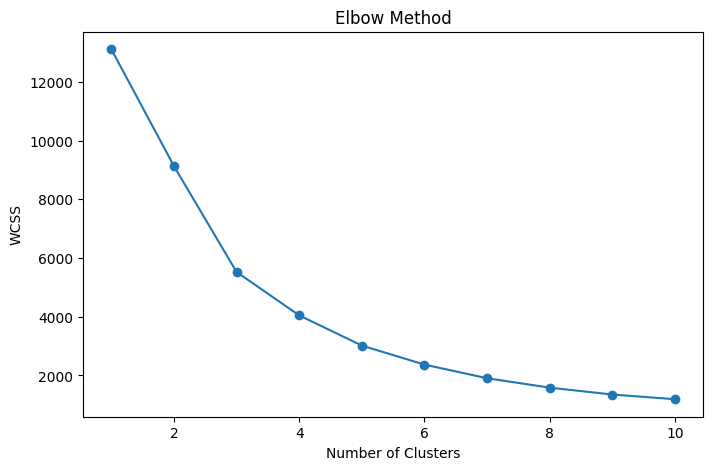

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**5. Apply K-Means Clustering**

Using the optimal number of clusters identified from the Elbow Method, we train the K-Means clustering model and assign each customer to a cluster.

In [30]:
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(
    rfm_clean[["Recency", "Frequency", "Monetary"]]
)

In [31]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
n_init=10
)
clusters = kmeans.fit_predict(rfm_scaled)
rfm_clean["Cluster"] = clusters
rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,0
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,0
12352.0,36,11,1545.41,1


In [32]:
print (rfm.shape)
print(rfm_clean.shape)
print(rfm_scaled.shape)

(4372, 3)
(3682, 4)
(3682, 3)


In [33]:
rfm_clean.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,0
12348.0,75,4,1797.24,2
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,0
12352.0,36,11,1545.41,1


In [34]:
rfm_clean["Cluster"].value_counts().sort_index()

,count
Cluster,
0,884
1,462
2,920
3,1416


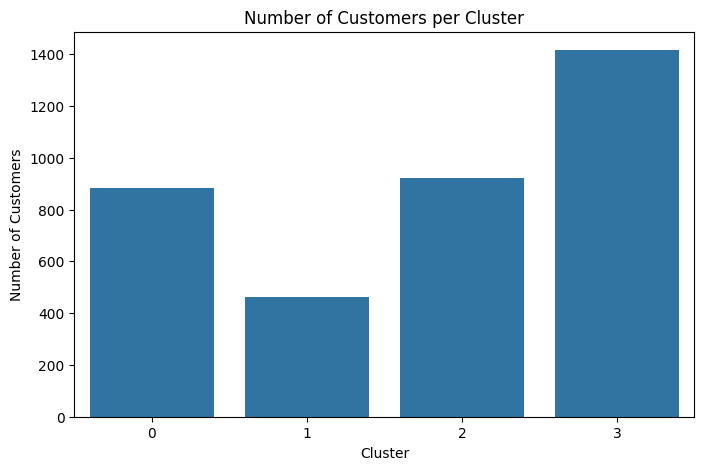

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=rfm_clean,
    x="Cluster"
)
plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

# **6. Cluster Profile**
Calculate the average Recency, Frequency and Monetary values for each cluster to understand customer behaviour.

In [36]:
cluster_profile = rfm_clean.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,232.712670,1.701357,375.920928
1,33.675325,7.541126,2337.330002
2,45.538043,4.478261,1147.439153
3,51.611582,1.721751,400.088568


# **Cluster Visualization (Recency vs Monetary)**
Visualise how customers are distributed across clusters.

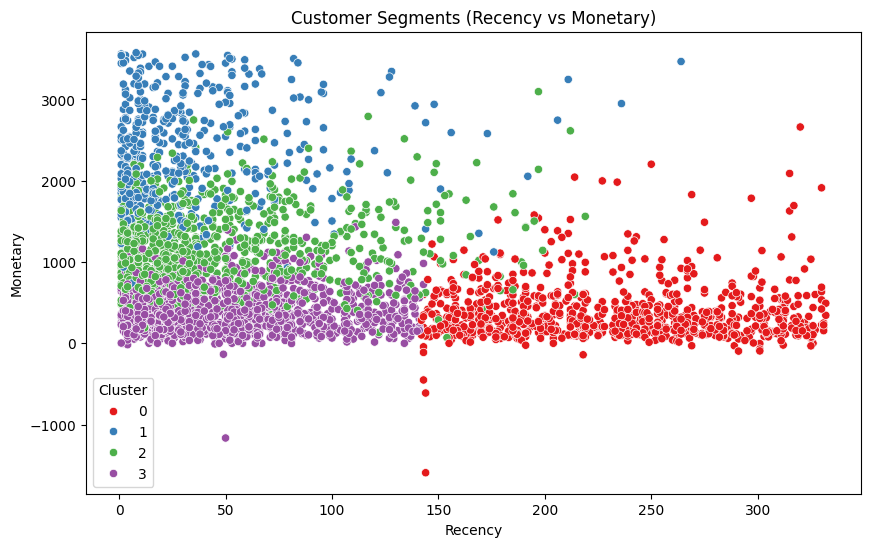

In [37]:
plt.figure(figsize=(10,6))
sns.scatterplot (
    data=rfm_clean,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)
plt.title("Customer Segments (Recency vs Monetary)")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

# **Cluster Visualization (Frequency vs Monetary)**
Visualize customer purchasing frequency against spending behaviour.

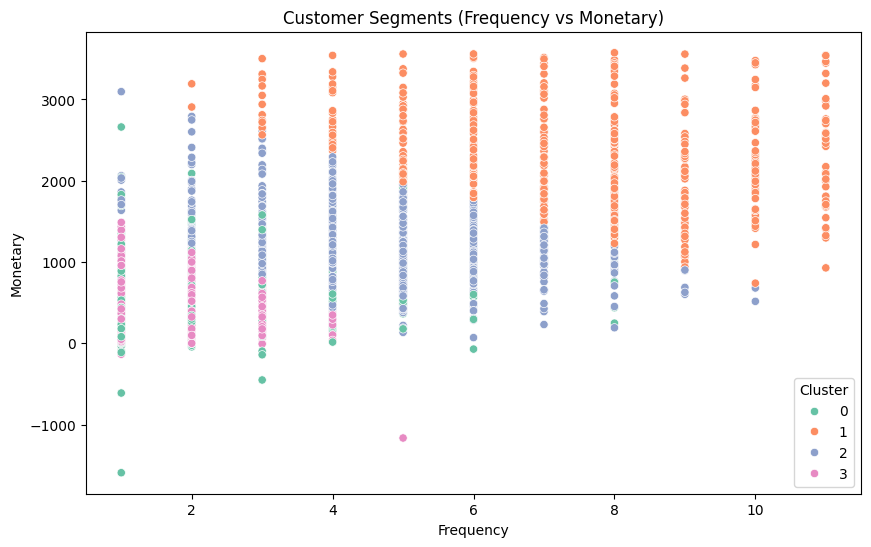

In [38]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm_clean,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)
plt.title("Customer Segments (Frequency vs Monetary)")
plt.show()

# **7. Cluster Profile**
The table below shows the average Recency, Frequency and Monetary value for each customer segment.

In [39]:
cluster_profile = rfm_clean.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,232.71,1.70,375.92
1,33.68,7.54,2337.33
2,45.54,4.48,1147.44
3,51.61,1.72,400.09


# **# 8. Marketing Recommendations**

**Cluster 0 - High-Value Loyal Customers**

*Purchase frequency and spend the most.

*Reward with loyalty programmes, VIP offers and exclusive discounts.

# **Cluster 1 - At-Risk Customers**
*Have not purchased for a long time.

*Send personalized emails, reminders and win-back promotions.

# **Cluster 2 - Regular Customers**
*Purchase occasionally with moderate spending.

*Encourage repeat purchases through product recommendations and seasonal offers.

# **Cluster 3 - New or Low-Spending Customers**
*Recently joined or spend relatively little.

*Introduce welcome discounts and cross-selling opportunites to increase engagement.

# **Conclusion**
Customer segmentation using RFM model and K-Means clustering successfully grouped customers based on purchasing behaviour. The analysis identified high-value customers, loyal customers, at-risk customers and low-value customers. These insights can help businesses design personalized marketing campaigns, improve customer retention and maximise revenue by targetting each customer segment appropriately.

# **Save Clustered Dataset**

In [40]:
rfm_clean.to_csv("customer_segments.csv", index=True)